In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm as tqdm
from statannotations.Annotator import Annotator

In [27]:
df_tad_ut_2024 = pd.read_csv('./loops/2024-02-and-04-Rep-HiC-UT-MRC5-WT-merged-rerun.merged_loops.bedpe',
            sep='\t', header=None)
df_tad_ut_2024[2] = df_tad_ut_2024[5]
df_tad_ut_2024 = df_tad_ut_2024.drop([3, 4, 5], axis=1)
df_tad_ut_2024['length'] = abs(df_tad_ut_2024[2] - df_tad_ut_2024[1])
df_tad_ut_2024

,0,1,2,length
0,chr1,1100000,1590000,490000
1,chr1,1225000,1875000,650000
2,chr1,1330000,1400000,70000
3,chr1,1400000,1510000,110000
4,chr1,1550000,1710000,160000
...,...,...,...,...
44750,chrY,19700000,21200000,1500000
44751,chrY,19800000,20750000,950000
44752,chrY,19890000,20050000,160000
44753,chrY,20400000,21390000,990000


In [28]:
df_timming = pd.read_csv('./timing_mrc5/timing_UT.bedGraph', sep='\t', header=None)
df_timming = df_timming[df_timming[3] != 0]
# df_early = pd.read_csv('/mnt/data/kaustav/Hi-c/Cut_and_Run/H3K9me3_CutnRun_repli-CutnRun/raw_data_20241101/sriram_data/seacr_peaks_normalized_by_NORM_function_seacr/RPE_early.bedGraph', sep='\t', header=None)
# df_late = pd.read_csv('/mnt/data/kaustav/Hi-c/Cut_and_Run/H3K9me3_CutnRun_repli-CutnRun/raw_data_20241101/sriram_data/seacr_peaks_normalized_by_NORM_function_seacr/RPE_late.bedGraph', sep='\t', header=None)
# print(len(df_early))
# print(len(df_late))
# df_timming = pd.merge(df_early, df_late, how='inner', on=[0, 1, 2])
# df_timming[4] = df_timming['3_x'] - df_timming['3_y']
# df_timming = df_timming.drop(['3_x', '3_y'], axis=1)
df_timming

,0,1,2,3
1,chr1,16250,16300,9.92703
2,chr1,16300,16350,15.79300
3,chr1,16350,16400,16.69550
4,chr1,16400,16450,13.53690
5,chr1,16450,16550,4.51230
...,...,...,...,...
28822981,KI270757.1,69750,69800,-8.54780
28822983,KI270757.1,70300,70450,-25.64340
28822984,KI270757.1,70450,70500,-5.12868
28822986,KI270757.1,70750,70800,-1.28217


In [29]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# threshold
per = 80
chunk_size = 2000  # adjust if you have more RAM/need more speed

# sort once for cache-friendly grouping
df_tad = df_tad_ut_2024.sort_values([0, 1, 2], kind="mergesort")
df_tim = df_timming.sort_values([0, 1, 2],   kind="mergesort")

results = []

for chrom, tad_chr in tqdm(df_tad.groupby(0), desc="Chromosomes"):
    tim_chr = df_tim[df_tim[0] == chrom]
    T = len(tad_chr)

    # default: NaN when a TAD contains no timing bins
    early_pct = np.full(T, np.nan, dtype=float)
    late_pct  = np.full(T, np.nan, dtype=float)

    if not tim_chr.empty:
        # timing arrays (USE COL 3 per your code)
        bin_st = tim_chr[1].to_numpy()
        bin_en = tim_chr[2].to_numpy()
        vals   = tim_chr[3].to_numpy()

        pos = vals > 0
        neg = vals < 0

        tad_st_all = tad_chr[1].to_numpy()
        tad_en_all = tad_chr[2].to_numpy()

        # chunk to avoid huge (TAD x bins) matrices
        for s in range(0, T, chunk_size):
            e = min(s + chunk_size, T)
            ts = tad_st_all[s:e][:, None]
            te = tad_en_all[s:e][:, None]

            # FULLY INSIDE condition
            inside = (bin_st >= ts) & (bin_en <= te)

            n_inside = inside.sum(axis=1)
            valid = n_inside > 0
            if not valid.any():
                continue

            pos_counts = (inside & pos).sum(axis=1)
            neg_counts = (inside & neg).sum(axis=1)

            early_pct[s:e][valid] = pos_counts[valid] / n_inside[valid] * 100.0
            late_pct[s:e][valid]  = neg_counts[valid] / n_inside[valid] * 100.0

    results.append(pd.DataFrame({
        'chr':   chrom,
        'start': tad_chr[1].to_numpy(),
        'end':   tad_chr[2].to_numpy(),
        'early': early_pct,
        'late':  late_pct,
    }))

df_per = pd.concat(results, ignore_index=True)

# same splits you had
df_per_early = df_per[df_per['early'] >= per]
df_per_late  = df_per[df_per['late']  >= per]
df_per_mid   = df_per[(df_per['early'] < per) & (df_per['late'] < per)]

print(len(df_per_early))
print(len(df_per_late))
print(len(df_per_mid))

Chromosomes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 24/24 [03:17<00:00,  8.23s/it]

5981
8848
29833


/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3142/1358569910.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_per_early['type'] = 'early'
/var/folders/c0/r1z251qj2mvczjs_mvjhpzqr0000gn/T/ipykernel_3142/1358569910.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_per_late['type'] = 'late'


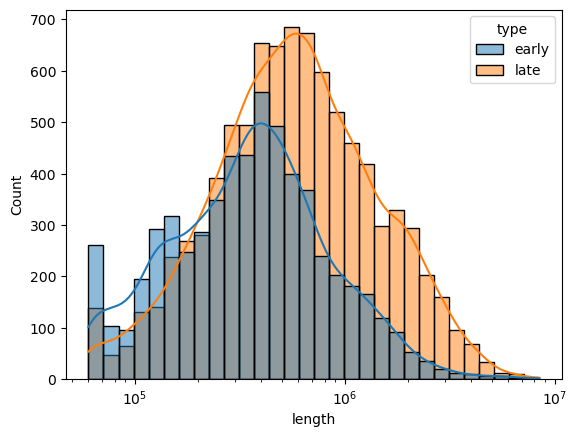

In [30]:
df_per_early['type'] = 'early'
df_per_late['type'] = 'late'
combined_df = pd.concat([df_per_early, df_per_late], ignore_index=True)
combined_df['length'] = combined_df['end'] - combined_df['start']
sns.histplot(data=combined_df, x="length", hue="type", bins=30, log_scale=True, kde=True)
plt.savefig('./fig_1/2024_HU_Unique_Loop_distribution_rep1.svg', dpi=1200, format='svg')
plt.show()